Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All). On JupyterLab, you may want to hit the "Validate" button as well.

Caution: do not mess with the notebook's metadata; do not change a pre-existing cell's type; do not copy pre-existing cells (add new ones with the + button instead). This will break autograding; you will get a 0; you are warned.

<table style="width: 100%; border: none;" cellspacing="0" cellpadding="0" border="0">
  <tr>
    <td><img src="https://www.ip-paris.fr/voeux2022-ecolepolytechnique/images/logo_p.png" style="float: left; width: 100%" />
</td>
    <td><a style="font-size: 3em; text-align: center; vertical-align: middle;" href="https://moodle.polytechnique.fr/course/view.php?id=19260">[CSC2S004EP - 2024] - Introduction to Machine Learning</a>
</td>
  </tr>
</table>

<a style="font-size: 3em;">Lab Session 14: Gaussian Mixture Models</a>

Jesse Read and Adrien Ehrhardt

# Introduction: Gaussian Mixture Models

In this lab we will have a look at Gaussian Mixture Models (GMMs) and some of their many uses, and how they connect to more advanced state of the art methods for generative machine learning.

A Gaussian Mixture Model (GMM) is a mixture of multidimensional Gaussian probability each given a different weight. You might consult the lecture slides and course notes for a reminder.  

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import multivariate_normal
from sklearn.mixture import GaussianMixture
from sklearn.datasets import fetch_openml

np.random.seed(42)

# Gaussian Mixture Model for Clustering

**Clustering** is one task that GMMs can be used for. We have one component (Gaussian) to represent each cluster. 

Lets re-introduce a dataset we used in lab 10 (for clustering), having $n$ instances of $d$ dimensions. 

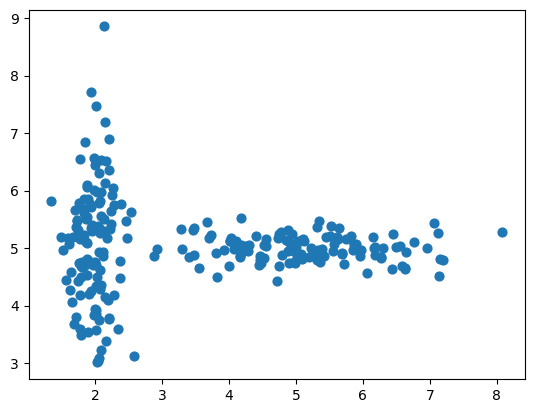

In [2]:
n = 120
d = 2
X = np.vstack([np.random.normal((2, 5), (0.25, 1), size=(n, d)), np.random.normal((5, 5), (1, 0.25), size=(n, d))])
plt.scatter(X[:, 0], X[:, 1], s=40);

Recall how k-Means clustering performs on such a dataset. 

In the following, use GMMs with Scikit-Learn to cluster this dataset. Put the result in `z`.

*Hints*: see imported [`GaussianMixture`](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html); use [`predict`](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture.predict).

*N.B.*: by default, scikit's Gaussian mixture uses k-means centroids to initialize itself.

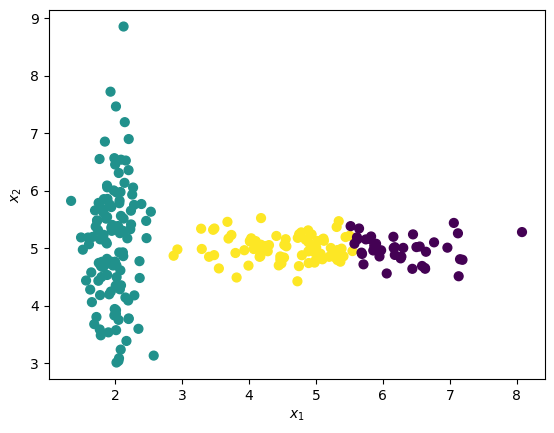

In [3]:
gmm = GaussianMixture(n_components=3, random_state=23).fit(X)

z = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=z, s=40, cmap='viridis');
plt.xlabel('$x_1$')
plt.ylabel('$x_2$');

Consult the slides and lecture notes for a reminder of how GMM is *learning* via [Expectation Maximization](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm).

# Gaussian Mixture Model for Probabilistic Clustering

We can also obtain $p(z = k \mid \mathbf{x})$ using the [`predict_proba`](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture.predict_proba) method in Scikit-Learn, i.e., providing a **probabilistic intertpretation**. This returns a matrix of size $n \times k$ (`[n_samples, n_clusters]`). Save this matrix to variable `P_z`, such that `P_z[i,j]` is the probability that the $i$-th instance belongs to the $j$-th cluster. 

In [4]:
P_z = gmm.predict_proba(X)

print(P_z[:10].round(3))

[[0.    0.995 0.005]
 [0.    1.    0.   ]
 [0.    0.999 0.001]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    1.    0.   ]
 [0.    0.999 0.001]
 [0.    1.    0.   ]]


We can visualise this uncertainty for example by drawing ellipses to represent the shape of each cluster, with points on the edge of the cluster having relatively lower probability to belong to it:

In [5]:
def plot_gmm(gmm, X):
    z = gmm.fit(X).predict(X)

    # Plot contour plot
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    xl = ax.get_xlim()
    yl = ax.get_ylim()
    
    # Define grid for contour plot
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Calculate probabilities for each point on the grid
    zz = np.zeros_like(xx)
    for i in range(gmm.n_components):
        mean = gmm.means_[i][:2]  # Extract mean for the first 2 dimensions
        covariances = gmm.covariances_[i][:2, :2]  # Extract covariance matrix for the first 2 dimensions
        mvn = multivariate_normal(mean=mean, cov=covariances)
        zz += gmm.weights_[i] * mvn.pdf(np.stack([xx.ravel(), yy.ravel()]).T).reshape(xx.shape)

    plt.contourf(xx, yy, zz, alpha=0.5, levels=10)
    plt.title('$p(\\mathbf{x})$')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    ax.set_xlim(xl)
    ax.set_ylim(yl)

In [9]:
def plot_gmm_spherical_cov(gmm, X):
    z = gmm.fit(X).predict(X)

    # Plot contour plot
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    xl = ax.get_xlim()
    yl = ax.get_ylim()
    
    # Define grid for contour plot
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Calculate probabilities for each point on the grid
    zz = np.zeros_like(xx)
    for i in range(gmm.n_components):
        mean = gmm.means_[i][:2]  # Extract mean for the first 2 dimensions
        covariances = gmm.covariances_[i]  # Extract covariance matrix for the first 2 dimensions
        mvn = multivariate_normal(mean=mean, cov=covariances)
        zz += gmm.weights_[i] * mvn.pdf(np.stack([xx.ravel(), yy.ravel()]).T).reshape(xx.shape)

    plt.contourf(xx, yy, zz, alpha=0.5, levels=10)
    plt.title('$p(\\mathbf{x})$')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    ax.set_xlim(xl)
    ax.set_ylim(yl)

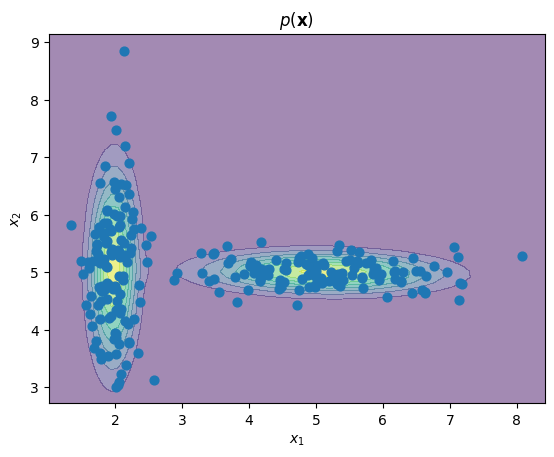

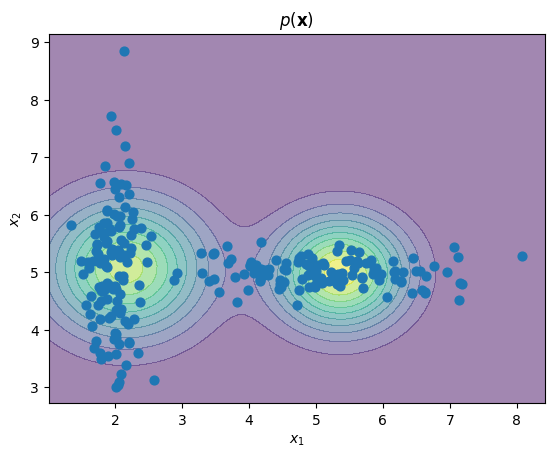

In [10]:
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=23)
plot_gmm(gmm, X)

# with spherical covariance
gmm = GaussianMixture(n_components=2, covariance_type='spherical', random_state=23)
plot_gmm_spherical_cov(gmm, X)

Note the parameter `covariance_type` option, which controls the degrees of freedom in the shape of each cluster. [Have a look at the options available for this parameter](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html); consider what is meant by `covariance_type="diag"` and  `covariance_type="spherical"` and `covariance_type="full"`. Which one is equivalent to using k-means clustering (in terms of resulting cluster shape)? **Qualitative answer expected in the cell below marked "YOUR ANSWER HERE".**

The closest option to k-means is covariance_type="spherical". That is because k-means assumes clusters to be sphetrical and of equal size, same as the definition of the spherical covariance type here.

By now it should be clear that GMMs address two main practical issues with *k*-means as encountered earlier: probabilistic interpretation, and cluster shape.

# Gaussian Mixture Models as Density Estimation

The GMM can also be used for **density estimation**, i.e., describing $p(\mathbf{x})$, the distribution of the data.

As an example, consider some data generated from Scikit-Learn's `make_moons` function: 

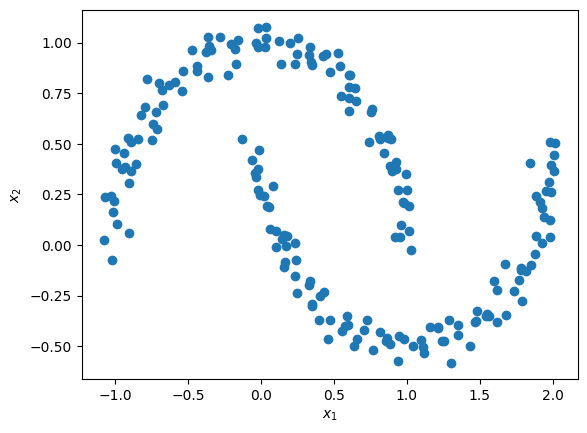

In [11]:
from sklearn.datasets import make_moons


Xmoon, ymoon = make_moons(200, noise=.05, random_state=0)
plt.scatter(Xmoon[:, 0], Xmoon[:, 1]);
plt.xlabel('$x_1$');
plt.ylabel('$x_2$');

With the following code we can visually appreciate that 2 components are insufficient to model this data distribution: 

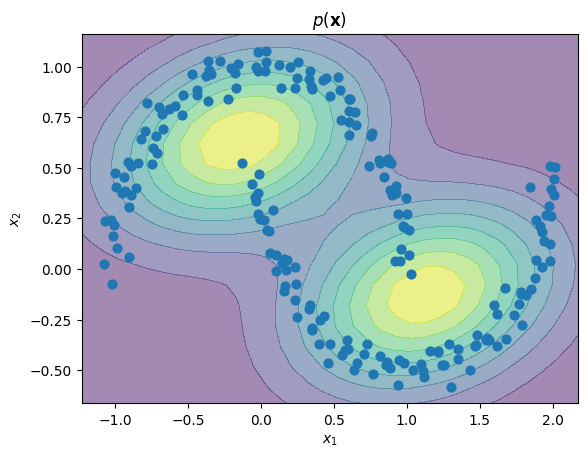

In [12]:
gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
plot_gmm(gmm2, Xmoon)

But try using more components; sufficient to get a reasonable approximation of this distribution.

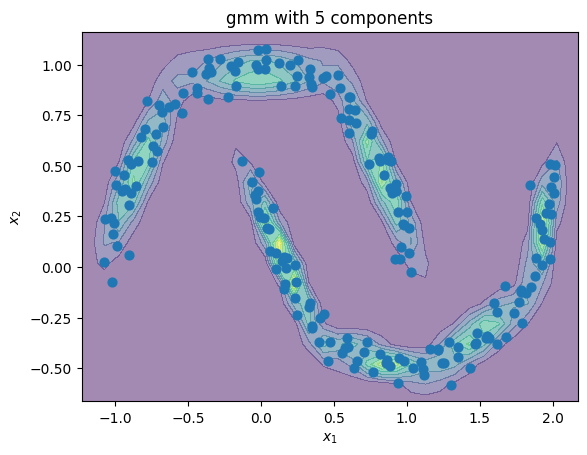

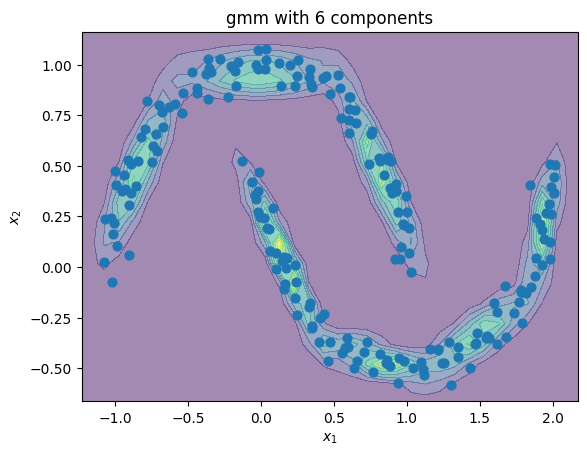

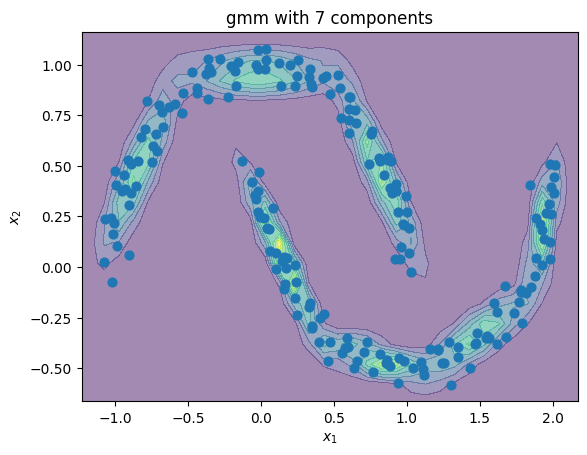

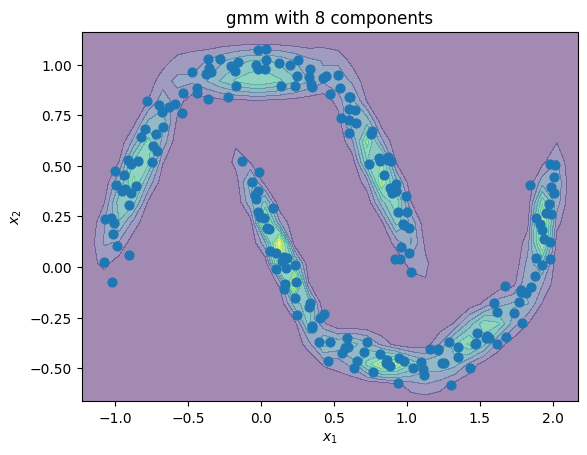

In [19]:
for n_c in [5, 6, 7, 8]:
    gmm_more_components = GaussianMixture(n_components=7, covariance_type='full', random_state=0)
    plot_gmm(gmm_more_components, Xmoon)
    # print(f"gmm with {n_c} components")
    plt.title(f"gmm with {n_c} components")
    plt.show()

# Gaussian Mixture Models as a Generative Model

As well as serving as a probability density to evaluate $p(\mathbf{x})$, we can also use a GMM to _sample_ $\mathbf{x} \sim p(\mathbf{x})$, i.e., a **generative model**.

Use your `gmm_more_components` with the `sample` method to generate 400 new points. Place the result into `Xnew`. 

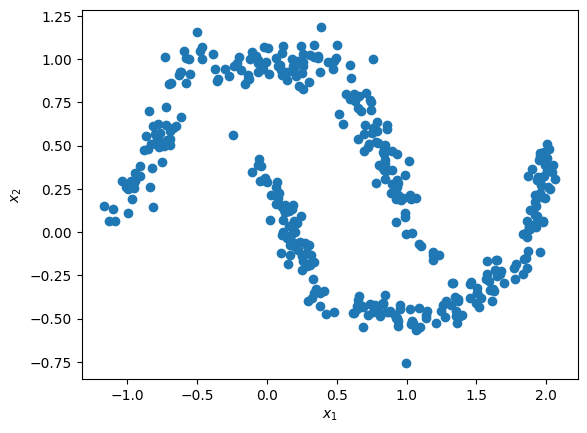

In [21]:
Xnew, ynew = gmm_more_components.sample(n_samples=400)

plt.scatter(Xnew[:, 0], Xnew[:, 1]);
plt.xlabel('$x_1$');
plt.ylabel('$x_2$');

## Choosing the number of components

What is the optimal number of components $m$?

We can simply evaluate the *likelihood* of the data under the model (as long as we take appropriate steps to avoid overfitting). In the following we make use of two criteria: [Akaike information criterion (AIC)](https://en.wikipedia.org/wiki/Akaike_information_criterion) and the [Bayesian information criterion (BIC)](https://en.wikipedia.org/wiki/Bayesian_information_criterion), to judge the quality of the mixture for a given number of components. Scikit-Learn's `GaussianMixture` estimator includes both, so there is not much code involved: 

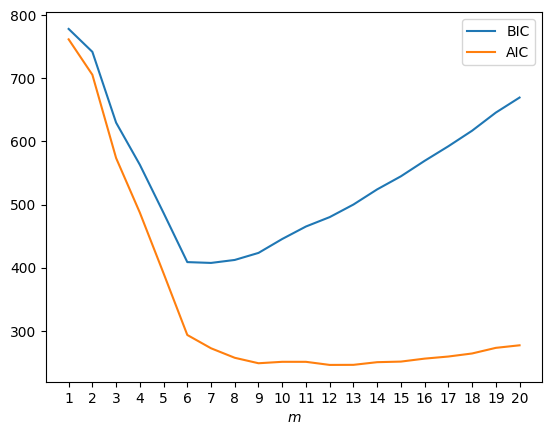

In [22]:
n_components_range = np.arange(1, 21)
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(Xmoon)
          for n in n_components_range]

plt.plot(n_components_range, [m.bic(Xmoon) for m in models], label='BIC')
plt.plot(n_components_range, [m.aic(Xmoon) for m in models], label='AIC')
plt.xlabel('$m$')
plt.xticks(n_components_range)
plt.legend(loc='best');

Which number of components do you choose? Note that the number of ideal components for modelling a distribution $p(\mathbf{x})$ is not necessarily the same number which is ideal for clustering $p(z=k | \mathbf{x})$.

In [23]:
n_components = 7


How does this relate to the **likelihood**? **Qualitative answer expected in cell below marked **YOUR ANSWER HERE**.

The evaluation methods we used (AIC and BIC) contain the log likelihood, as well as a penalty for model complexity. Therefore, this image is close to a likelihood estimator, with a small penalty for larger models. Considering this and looking at the AIC graph (-2 lnL_hat + 2k, where k is the number of components of the model), the maximum likelihood might lie around 13 or 14, or even further, since the penalty for no. of components is growing while the AIC value platoes.

## Gaussian Mixture Models and PCA/Auto-Encoders

A major limitation of GMMs is that they are difficult to get good results from in high-dimensions. So if $\mathbf{x}$ is high dimensional (for example, the MNIST data), $p(\mathbf{x})$ will likely not be excellent. 

Let's address this issue by first obtaining a more compact representation, i.e., $\mathbf{z}$. You have already done exactly this kind of task in Lab 11 using linear and non-linear Auto-Encoders. 

First, let's get the MNIST data, and remind ourselves of what it looks like. 

Let's take only the 0s and 1s, to make the computation a little bit lighter. 

In [24]:
# Fetch MNIST dataset
mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')

# Extract features and labels
X, y = mnist['data'], mnist['target']
y = y.astype(int)

X = X[(y == 0) | (y == 1)]
y = y[(y == 0) | (y == 1)]

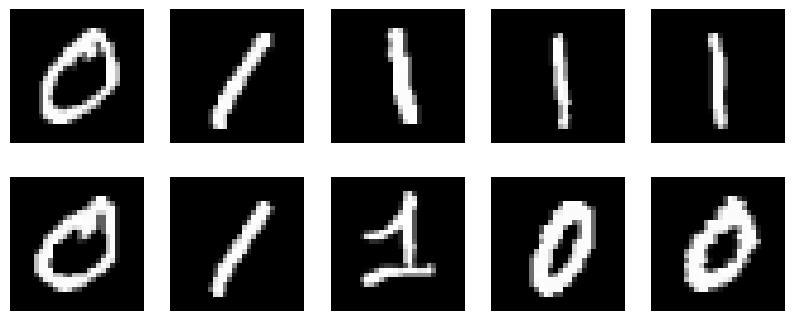

In [25]:
X = np.array(X)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i, :].reshape(28, 28), cmap='gray')
    ax.axis('off')

Use PCA (100 components) to create the dataset in `Z`-space:

In [26]:
from sklearn.decomposition import PCA

In [27]:
pca = PCA(n_components=20, whiten=True)
Z = pca.fit_transform(X)

Given this latent representation of the dataset, $\mathbf{z}_1,\ldots,\mathbf{z}_n$, try to estimate a the number of GMM components we should use (see the following figure):

**Hint** If this takes too long, start by using a random subsets of instances (several thousand - you may get warnings that the algorithm did not converge, so there is a tradeoff there), and `max_iter` with a reasonably small value (e.g., 5 or 10).

m= 1  AIC=285061  BIC=286559  converged=True
m= 2  AIC=168371  BIC=171376  converged=False
m= 3  AIC=157322  BIC=161832  converged=False


C:\Users\raula\AppData\Roaming\Python\Python313\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\raula\AppData\Roaming\Python\Python313\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\raula\AppData\Roaming\Python\Python313\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


m= 4  AIC=140110  BIC=146126  converged=False
m= 5  AIC=115329  BIC=122850  converged=False


C:\Users\raula\AppData\Roaming\Python\Python313\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\raula\AppData\Roaming\Python\Python313\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


m= 6  AIC=110193  BIC=119219  converged=False
m= 7  AIC=103836  BIC=114367  converged=False


...

C:\Users\raula\AppData\Roaming\Python\Python313\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


m=28  AIC=73436  BIC=115583  converged=False


C:\Users\raula\AppData\Roaming\Python\Python313\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


m=29  AIC=73389  BIC=117041  converged=False
m=30  AIC=72620  BIC=117778  converged=False


C:\Users\raula\AppData\Roaming\Python\Python313\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


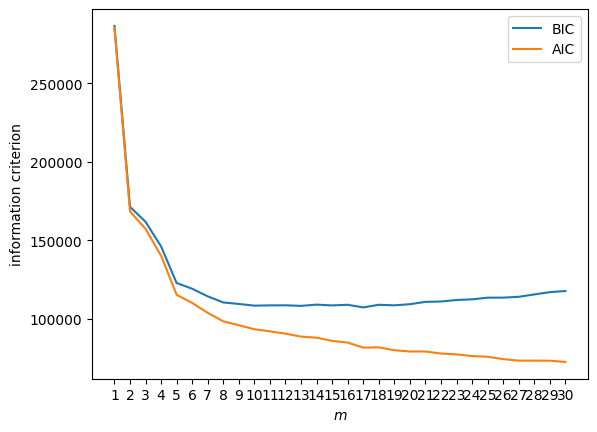

BIC minimum at m = 17
AIC minimum at m = 30


In [28]:
# TODO some parameter search here

rng = np.random.default_rng(0)
n_sub = 5000
idx = rng.choice(len(Z), size=min(n_sub, len(Z)), replace=False)
Z_sub = Z[idx]

m_values = np.arange(1, 31)
aic, bic = [], []

for m in m_values:
    gmm = GaussianMixture(
        n_components=m,
        covariance_type='full',
        max_iter=10,                      # small, per the hint
        n_init=1,
        random_state=0,
    )
    gmm.fit(Z_sub)
    aic.append(gmm.aic(Z_sub))
    bic.append(gmm.bic(Z_sub))
    print(f"m={m:2d}  AIC={aic[-1]:.0f}  BIC={bic[-1]:.0f}  converged={gmm.converged_}")

# --- Plot ---
plt.plot(m_values, bic, label='BIC')
plt.plot(m_values, aic, label='AIC')
plt.xlabel('$m$')
plt.ylabel('information criterion')
plt.xticks(m_values)
plt.legend()
plt.show()

# --- Pick the minimum (BIC is the conservative choice) ---
m_best_bic = m_values[np.argmin(bic)]
m_best_aic = m_values[np.argmin(aic)]
print(f"BIC minimum at m = {m_best_bic}")
print(f"AIC minimum at m = {m_best_aic}")

In [29]:
n_components = 17

Let's remove the constraint on the number of iterations and check whether the algorithm has converged, on the full latent data `Z`: 

In [30]:
gmm = GaussianMixture(n_components, covariance_type='full', random_state=0)
gmm.fit(Z)
print(gmm.converged_)

True


Draw 10 new points using your GMM as a generative model (put them in `Z_new`), and plot the results in data space (i.e., visualise the numbers, e.g., using `imshow` as in earlier tutorials). So, you'll need to reconstruct back into the data space, using the same instantiation of PCA as earlier (put them in `X_new`). 

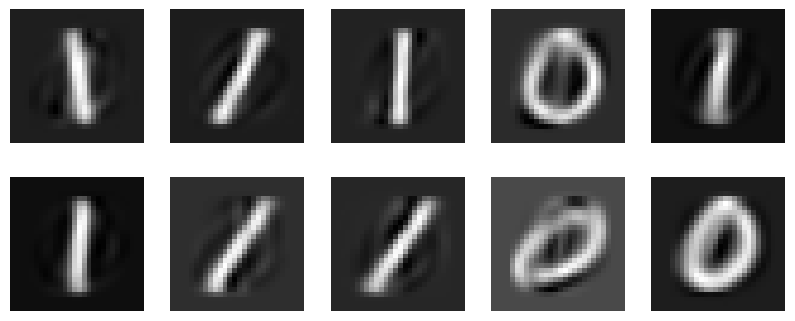

In [33]:
Z_new, y_new = gmm.sample(10)  # the drawn new samples in PC-space
X_new = pca.inverse_transform(Z_new) # the drawn new samples in original data space

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_new[i, :].reshape(28, 28), cmap='gray')
    ax.axis('off')

Does the result look like plausible digits from the dataset?

Can do you do better with a non-linear Auto Encoder? Encapsulate your work in class `MyAutoEncoder`, which should have functions `fit(self, X, n_epochs)`, `transform(self, X, n_epochs)` and `inverse_transform(self, Z)` (much like PCA in Scikit-Learn's implementation). 

(You may ignore warnings from the import cell below).

In [34]:
import tensorflow as tf
import tensorflow.keras.datasets.mnist as mnist
from tensorflow.keras.layers import Dense, Input, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from tensorflow.keras import Model

In [63]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Reshape

class MyAutoEncoder:
    def __init__(self, input_size: int, code_size: int):
        
        if isinstance(input_size, int):
            self.input_shape = (input_size,)
        else:
            self.input_shape = tuple(input_size)
        self.flat_size = int(np.prod(self.input_shape))

        # encoder 
        inp = Input(shape=(self.flat_size,))
        # h = Reshape((flat_size,))(inp)
        h = Dense(256, activation='relu')(inp)
        h = Dense(64,  activation='relu')(h)
        z  = z = Dense(code_size, name='code')(h)
        
        # decoder
        h = Dense(64,  activation='relu')(z)
        h = Dense(256, activation='relu')(h)
        out = Dense(self.flat_size, activation='sigmoid')(h)   # sigmoid for [0,1] pixels
        # out = Reshape(self.input_shape)(h)

        # Full autoencoder
        self.autoencoder = Model(inp, out)
        self.autoencoder.compile(optimizer=Adam(1e-3), loss='mse')

        self.encoder = Model(inp, z)

        code_inp = Input(shape=(code_size,))

        dec_layers = self.autoencoder.layers[-3:]
        x = code_inp
        for layer in dec_layers:
            x = layer(x)
        self.decoder = Model(code_inp, x)

    def fit(self, X, n_epochs=7):
        Xf = self._flatten(X)
        self.autoencoder.fit(
            Xf, Xf,
            epochs=n_epochs,
            batch_size=256,
            shuffle=True,
            verbose=1,
        )
        return self

    def _flatten(self, X):
        return X.reshape(X.shape[0], -1)

    def _unflatten(self, X_flat):
        return X_flat.reshape((-1,) + self.input_shape)

    def transform(self, X, n_epochs=7):
        return self.encoder.predict(self._flatten(X), verbose=0)

    def inverse_transform(self, Z):
        X_flat = self.decoder.predict(Z, verbose=0)
        return self._unflatten(X_flat) 

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [71]:
nae = MyAutoEncoder((28, 28), 20)
X_norm = X.astype('float32') / 255.0
nae.fit(X_norm.reshape((X_norm.shape[0], 28, 28)), n_epochs=10)
Z_ae = nae.transform(X_norm.reshape((X_norm.shape[0], 28, 28)))

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0799
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0366
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0257
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0197
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0159
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0136
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0121
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0111
Epoch 9/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104
Epoch 10/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0098


Again, let's do GMM on the (now non-linear) representation with fewer components:

In [72]:
gmm_ae = GaussianMixture(n_components=80, covariance_type='full', reg_covar=1e-2, random_state=0)
gmm_ae.fit(Z_ae)
print(gmm_ae.converged_)

True


Draw 10 new points using your GMM as a generative model (put them in `Z_ae_new`), and plot the results in data space (i.e., visualise the numbers, e.g., using `imshow` as in earlier tutorials). So, you'll need to reconstruct back into the data space, using the same instantiation of your non-linear autoencoder as earlier (put them in `X_ae_new`).

C:\Users\raula\AppData\Roaming\Python\Python313\site-packages\sklearn\mixture\_base.py:468: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


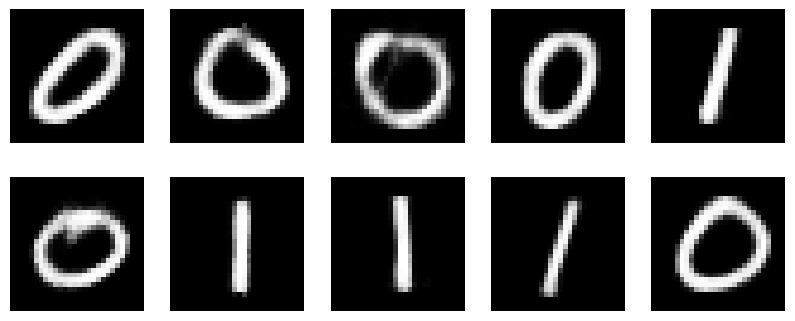

In [73]:
Z_ae_new, y_ae_new = gmm_ae.sample(10)
X_ae_new = nae.inverse_transform(Z_ae_new)
# 
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_ae_new[i, :].reshape(28, 28), cmap='gray')
    ax.axis('off')

# Conclusion and Beyond GMMs
GMMs are very useful! And furthermore, we are now very close to Variational Auto-Encoders, where we can leverage the potentially unlimited modelling capacity of deep neural networks for $p(\mathbf{x})$ (as we do already for the Encoder). The only thing we'd like to do is have a full end-to-end pipeline, such that the encoding (of $\mathbf{z}$) and the representation of $p(\mathbf{x})$ are not disconnected. 